#**Machine Learning-Based Revenue Forecasting and Onboarding Patterns Across Multi-Country Payment Networks**: A Case Study of Arab Financial Services

## **This Notebook: Merchant Value Classification (Bahrain — Ahli United Bank)**
Classifying merchants into **High**, **Medium**, or **Low** value tiers using real transaction data.

#section 1: Import Libraries & Connect to Google Drive

In [ ]:
# --- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Core libraries ---
import pandas as pd
import numpy as np

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# --- Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, KFold

# --- Modelling ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
!pip install catboost -q
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Evaluation ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# --- Display settings ---
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# --- File path ---
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Thesis/Thesis_Datasets/BH_AUB_merchant_details_dataset.xlsx'

print('Setup complete.')
print('Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
Setup complete.
Libraries loaded: pandas, numpy, matplotlib, seaborn, sklearn, xgboost


#SECTION 2: Data Structure

In [ ]:
# --- Load dataset ---
df = pd.read_excel(FILE_PATH)
df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('Columns:', list(df.columns))
print()

# --- Data structure overview ---
print('Unique merchants (MID):', df['MID'].nunique())
print()
print('Column fill rates:')
for c in df.columns:
    missing = df[c].isna().sum()
    print(f'  {c:<28} {missing:>7,} missing')

# --- Onboarding date range ---
onboard_dates = pd.to_datetime(df['OnboardingDate'], errors='coerce')
print(f'\nOnboardingDate range: {onboard_dates.min().date()} to {onboard_dates.max().date()}')

# --- Settlement date range (Year/Month columns) ---
settlement_years = pd.to_numeric(df['Settlement Year'], errors='coerce')
settlement_months = pd.to_numeric(df['Settlement Month'], errors='coerce')
min_idx = (settlement_years * 12 + settlement_months).idxmin()
max_idx = (settlement_years * 12 + settlement_months).idxmax()
print(f'Settlement range: {int(settlement_years[min_idx])}-{int(settlement_months[min_idx]):02d} '
      f'to {int(settlement_years[max_idx])}-{int(settlement_months[max_idx]):02d}')

# --- Preview raw data ---
df.head(10)

Shape: (85150, 12)
Columns: ['Transactions Count', 'Transaction Amount', 'Average Transaction Amount', 'DATASOURCE', 'Settlement Month', 'Settlement Year', 'MID', 'isActive', 'status', 'riskLevel', 'BusinessType', 'OnboardingDate']

Unique merchants (MID): 3819

Column fill rates:
  Transactions Count                 0 missing
  Transaction Amount                 0 missing
  Average Transaction Amount         0 missing
  DATASOURCE                         0 missing
  Settlement Month                   0 missing
  Settlement Year                    0 missing
  MID                                0 missing
  isActive                          21 missing
  status                            83 missing
  riskLevel                         68 missing
  BusinessType                      88 missing
  OnboardingDate                   240 missing

OnboardingDate range: 2019-01-01 to 2025-11-01
Settlement range: 2019-01 to 2026-06


,Transactions Count,Transaction Amount,Average Transaction Amount,DATASOURCE,Settlement Month,Settlement Year,MID,isActive,status,riskLevel,BusinessType,OnboardingDate
0,2340,"50,582.14",21.62,AUBPOSTILION,7,2025,200000,1.00,2.00,2.00,Department Stores,2025-07-01
1,5874,"47,900.58",8.15,AUB,8,2025,200000,1.00,2.00,2.00,Department Stores,2025-07-01
2,1716,"37,817.02",22.04,AUB,9,2025,200000,1.00,2.00,2.00,Department Stores,2025-07-01
3,420,"36,686.98",87.35,AUBPOSTILION,10,2025,200000,1.00,2.00,2.00,Department Stores,2025-07-01
4,81,"3,127.13",38.61,AUB,4,2023,200001,1.00,3.00,2.00,Miscellaneous Home Furnishing Specialty Stores,2023-04-01
5,456,"3,153.30",6.92,AUBPOSTILION,5,2023,200001,1.00,3.00,2.00,Miscellaneous Home Furnishing Specialty Stores,2023-04-01
6,266,"3,138.21",11.80,AUBPOSTILION,6,2023,200001,1.00,3.00,2.00,Miscellaneous Home Furnishing Specialty Stores,2023-04-01
7,176,"2,805.03",15.94,AUB,7,2023,200001,1.00,3.00,2.00,Miscellaneous Home Furnishing Specialty Stores,2023-04-01
8,71,"3,094.76",43.59,AUBPOSTILION,8,2023,200001,1.00,3.00,2.00,Miscellaneous Home Furnishing Specialty Stores,2023-04-01
9,872,"8,694.55",9.97,AUBPOSTILION,9,2023,200002,1.00,2.00,2.00,"Public Warehousing-Farm products, Refrigerated...",2023-09-01


#SECTION 3: Data Cleaning

###Data was cleaned by converting numeric columns, parsing onboarding dates, removing invalid transaction records, dropping non-informative columns, imputing missing values, label-encoding BusinessType, and excluding merchants onboarded less than one year before the most recent settlement date if any

In [ ]:
# --- Capture BEFORE counts ---
rows_before = len(df)
merchants_before = df['MID'].nunique()
print(f'BEFORE cleaning: {rows_before:,} rows | {merchants_before:,} merchants')

# --- Convert numeric columns ---
numeric_cols = ['Transaction Amount', 'Transactions Count', 'Average Transaction Amount',
                'Settlement Year', 'Settlement Month', 'riskLevel', 'status']
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# --- Parse onboarding date ---
df['OnboardingDate'] = pd.to_datetime(df['OnboardingDate'], errors='coerce')
df = df.dropna(subset=['OnboardingDate'])

# --- Remove negative amounts & counts ---
df = df[(df['Transactions Count'] > 0) & (df['Transaction Amount'] > 0)]

# --- Drop non-useful columns ---
df = df.drop(columns=['isActive'])             # nearly all active — no predictive variation
df = df.drop(columns=['DATASOURCE'])           # all same value

# --- Handle missing values ---
df['BusinessType'] = df['BusinessType'].fillna('Unknown')     # keep as its own category
df['status'] = df['status'].fillna(df['status'].median())     # fill with median
df['riskLevel'] = df['riskLevel'].fillna(df['riskLevel'].median())

# --- Encode BusinessType  ---
df['BusinessType'] = LabelEncoder().fit_transform(df['BusinessType'].astype(str))

# --- Exclude merchants onboarded less than 1 year before the dataset's latest date ---
# Reference date = the most recent Settlement Year/Month present in the data
reference_date = pd.Timestamp(
    year=int(df['Settlement Year'].max()),
    month=int(df.loc[df['Settlement Year'] == df['Settlement Year'].max(), 'Settlement Month'].max()),
    day=1)
one_year_cutoff = reference_date - pd.DateOffset(years=1)

merchants_before_age_filter = df['MID'].nunique()
df = df[df['OnboardingDate'] <= one_year_cutoff]
merchants_after_age_filter = df['MID'].nunique()

print(f'\nReference date (latest settlement in data): {reference_date.date()}')
print(f'1-year cutoff (merchants must be onboarded on/before this): {one_year_cutoff.date()}')
print(f'Merchants removed for being onboarded < 1 year ago: '
      f'{merchants_before_age_filter - merchants_after_age_filter:,}')

# --- Cleaning summary (before vs after) ---
rows_after = len(df)
merchants_after = df['MID'].nunique()
print(f'\nAFTER cleaning:  {rows_after:,} rows | {merchants_after:,} merchants')
print(f'Removed:         {rows_before - rows_after:,} rows '
      f'({(rows_before - rows_after)/rows_before*100:.1f}%)')

# --- Preview cleaned data ---
df.head(10)

BEFORE cleaning: 85,150 rows | 3,819 merchants

Reference date (latest settlement in data): 2026-06-01
1-year cutoff (merchants must be onboarded on/before this): 2025-06-01
Merchants removed for being onboarded < 1 year ago: 229

AFTER cleaning:  79,291 rows | 3,590 merchants
Removed:         5,859 rows (6.9%)


,Transactions Count,Transaction Amount,Average Transaction Amount,Settlement Month,Settlement Year,MID,status,riskLevel,BusinessType,OnboardingDate
4,81,"3,127.13",38.61,4,2023,200001,3.00,2.00,115,2023-04-01
5,456,"3,153.30",6.92,5,2023,200001,3.00,2.00,115,2023-04-01
6,266,"3,138.21",11.80,6,2023,200001,3.00,2.00,115,2023-04-01
7,176,"2,805.03",15.94,7,2023,200001,3.00,2.00,115,2023-04-01
8,71,"3,094.76",43.59,8,2023,200001,3.00,2.00,115,2023-04-01
9,872,"8,694.55",9.97,9,2023,200002,2.00,2.00,136,2023-09-01
10,475,"6,878.03",14.48,10,2023,200002,2.00,2.00,136,2023-09-01
11,443,"5,254.75",11.86,11,2023,200002,2.00,2.00,136,2023-09-01
12,96,"3,921.93",40.85,12,2023,200002,2.00,2.00,136,2023-09-01
13,44,"3,079.51",69.99,1,2024,200002,2.00,2.00,136,2023-09-01


#SECTION 4: Feature Extraction --> 3 values (High/Low/Medium)

###Merchant value tier labels were assigned by ranking each merchant's average later-period (months 7-12) transaction amount against all other merchants: **the bottom 20% were labeled Low, the top 20% High, and the remaining 60% Medium.** Early-life features including transaction aggregates, business type, and month-over-month growth rates were engineered from each merchant's first 6 months of activity to serve as history used to predict that later outcome

In [ ]:
# --- Record date + merchant age (months since onboarding) ---
df['RecordDate'] = pd.to_datetime(dict(
    year=df['Settlement Year'].astype(int),
    month=df['Settlement Month'].astype(int),
    day=1))
df['age'] = ((df['RecordDate'].dt.year - df['OnboardingDate'].dt.year) * 12 +
             (df['RecordDate'].dt.month - df['OnboardingDate'].dt.month))
df = df[df['age'] >= 0]

# ---- LABEL: 3-tier value class from a FIXED later-period window (age 7 to 12) ----
later = df[(df['age'] > 6) & (df['age'] <= 12)]
eventual = later.groupby('MID')['Transaction Amount'].mean()
p20, p80 = eventual.quantile(0.20), eventual.quantile(0.80)

def assign_tier(v):
    if v <= p20:  return 0     # Low
    elif v >= p80: return 2    # High
    return 1                   # Medium

labels = eventual.apply(assign_tier)

# ---- EARLY-LIFE FEATURES: first 6 months only (age <= 6) ----
early = df[df['age'] <= 6]

feat = early.groupby('MID').agg(
    early_total_amount=('Transaction Amount', 'sum'),
    early_avg_amount=('Transaction Amount', 'mean'),
    early_max_amount=('Transaction Amount', 'max'),
    early_std_amount=('Transaction Amount', 'std'),
    early_total_count=('Transactions Count', 'sum'),
    early_avg_count=('Transactions Count', 'mean'),
    #early_active_months=('RecordDate', 'nunique'),
    risk=('riskLevel', 'median'),
    status=('status', 'median'),
).reset_index()

# --- Most common business type per merchant ---
bt = early.groupby('MID')['BusinessType'].agg(lambda x: x.mode().iloc[0]).reset_index()
feat = feat.merge(bt, on='MID', how='left')

# --- Per-month transaction amount, aligned by age 0..6 ---
monthly = early.groupby(['MID', 'age'])['Transaction Amount'].sum().unstack()
monthly = monthly.reindex(columns=[0, 1, 2, 3, 4, 5, 6])
monthly.columns = [f'm{c}' for c in monthly.columns]

for k in range(2, 7):
    prev, cur = f'm{k-1}', f'm{k}'
    monthly[f'growth_{k}'] = (monthly[cur] - monthly[prev]) / (monthly[prev].abs() + 1)
    monthly[f'growth_{k}'] = monthly[f'growth_{k}'].clip(-1, 10)

growth_cols = ['growth_2', 'growth_3', 'growth_4', 'growth_5', 'growth_6']
monthly = monthly[growth_cols].reset_index()
feat = feat.merge(monthly, on='MID', how='left')

# --- Merge features + label ---
data = feat.merge(labels.rename('tier'), on='MID', how='inner')

# --- Log-transform skewed monetary features ---
log_cols = ['early_total_amount', 'early_avg_amount', 'early_max_amount',
            'early_std_amount', 'early_total_count', 'early_avg_count']
for c in log_cols:
    data[c] = np.log1p(data[c].clip(lower=0))

data = data.fillna(0)

print('Final dataset:', len(data), 'merchants')
print('Class distribution:')
print('  Low   :', (data['tier'] == 0).sum())
print('  Medium:', (data['tier'] == 1).sum())
print('  High  :', (data['tier'] == 2).sum())

data.tail(10)

Final dataset: 3067 merchants
Class distribution:
  Low   : 614
  Medium: 1839
  High  : 614


,MID,early_total_amount,early_avg_amount,early_max_amount,early_std_amount,early_total_count,early_avg_count,risk,status,BusinessType,growth_2,growth_3,growth_4,growth_5,growth_6,tier
3057,203804,10.80,8.86,9.25,7.61,7.80,5.86,1.00,3.00,130,0.11,0.15,0.07,0.22,0.17,1
3058,203805,10.12,8.17,8.54,6.85,7.07,5.12,2.00,2.00,46,0.10,0.10,0.10,0.14,0.20,1
3059,203807,10.79,8.85,9.20,7.48,8.57,6.62,2.00,3.00,161,0.10,0.14,0.11,0.06,0.22,1
3060,203808,9.33,7.38,7.56,5.22,7.22,5.27,2.00,2.00,39,0.03,0.03,0.04,0.16,-0.08,1
3061,203810,9.58,7.63,8.23,6.89,6.83,4.89,4.00,3.00,122,0.22,0.22,0.17,0.33,0.30,2
3062,203811,8.07,6.28,6.63,5.22,5.50,3.73,3.00,2.00,29,0.00,0.00,0.16,0.23,0.07,1
3063,203813,8.86,6.91,7.07,4.92,6.29,4.35,0.00,1.00,46,-0.08,-0.11,-0.02,-0.02,-0.09,0
3064,203814,9.76,7.82,7.91,5.21,6.74,4.80,2.00,1.00,113,0.15,-0.09,0.06,0.08,-0.06,1
3065,203815,11.44,9.49,9.60,6.69,8.68,6.74,2.00,2.00,44,-0.01,0.02,0.07,-0.01,0.10,1
3066,203818,7.02,5.08,5.40,3.69,4.28,2.41,1.00,2.00,76,0.11,0.20,0.10,0.05,0.18,0


#SECTION 5: Train/Test Split

###Merchants were split into training and test sets based on onboarding date, with those onboarded before May 2024 used for training and those onboarded between May 2024 and June 2025 held out as a chronological test set

In [ ]:
# --- Attach each merchant's OnboardingDate to the feature table ---
onboard_dates = df.groupby('MID')['OnboardingDate'].first().reset_index()
data_with_date = data.merge(onboard_dates, on='MID', how='left')

# --- Define the test window: merchants onboarded 2024-05-01 to 2025-06-01 ---
test_start = pd.Timestamp('2024-05-01')
test_end = pd.Timestamp('2025-06-01')

train_mask = data_with_date['OnboardingDate'] < test_start
test_mask = (data_with_date['OnboardingDate'] >= test_start) & (data_with_date['OnboardingDate'] <= test_end)

print(f'Train: merchants onboarded before {test_start.date()}')
print(f'Test : merchants onboarded {test_start.date()} to {test_end.date()}')
print(f'\nTrain merchants: {train_mask.sum()}')
print(f'Test merchants : {test_mask.sum()}')

# --- Time-based train/test split (BusinessType already label-encoded in Section 1) ---
FEATURES = ['early_total_amount', 'early_avg_amount', 'early_max_amount',
            'early_std_amount', 'early_total_count', 'early_avg_count',
            'risk', 'status', 'BusinessType',
            'growth_2', 'growth_3', 'growth_4', 'growth_5', 'growth_6']

X = data_with_date[FEATURES]
y = data_with_date['tier'].values

X_train = X[train_mask].reset_index(drop=True)
X_test = X[test_mask].reset_index(drop=True)
y_train = y[train_mask.values]
y_test = y[test_mask.values]

print('\nFeatures used:', FEATURES)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

print('\nTrain class distribution:')
print(pd.Series(y_train).value_counts().sort_index())
print('\nTest class distribution:')
print(pd.Series(y_test).value_counts().sort_index())

Train: merchants onboarded before 2024-05-01
Test : merchants onboarded 2024-05-01 to 2025-06-01

Train merchants: 2610
Test merchants : 457

Features used: ['early_total_amount', 'early_avg_amount', 'early_max_amount', 'early_std_amount', 'early_total_count', 'early_avg_count', 'risk', 'status', 'BusinessType', 'growth_2', 'growth_3', 'growth_4', 'growth_5', 'growth_6']
Train shape: (2610, 14)  Test shape: (457, 14)

Train class distribution:
0     514
1    1565
2     531
Name: count, dtype: int64

Test class distribution:
0    100
1    274
2     83
Name: count, dtype: int64


#SECTION 6: Class Imbalance Handling

###SMOTE was applied to the training set only, generating synthetic samples for the Low and High tiers up to 80% of the Medium class size to address class imbalance, while the test set remained untouched to preserve realistic evaluation conditions

CLASS DISTRIBUTION BEFORE SMOTE (training set):
  Low    :   514  (20%)
  Medium :  1565  (60%)
  High   :   531  (20%)
  Total  : 2610

CLASS DISTRIBUTION AFTER SMOTE (training set):
  Low    :  1252  (31%)
  Medium :  1565  (38%)
  High   :  1252  (31%)
  Total  : 4069


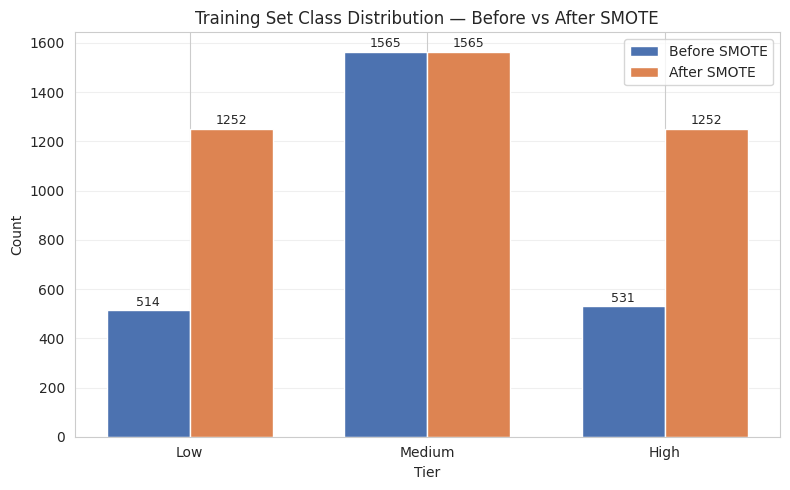

In [ ]:
print('CLASS DISTRIBUTION BEFORE SMOTE (training set):')
before = np.bincount(y_train)
for cls, n in zip(['Low', 'Medium', 'High'], before):
    print(f'  {cls:<7}: {n:>5}  ({n/len(y_train)*100:.0f}%)')
print(f'  Total  : {len(y_train)}')

# Targets set relative to the majority class (Medium)
majority_count = before[1]
target_low = max(before[0], int(majority_count * 0.8))
target_high = max(before[2], int(majority_count * 0.8))

smote = SMOTE(sampling_strategy={0: target_low, 2: target_high}, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nCLASS DISTRIBUTION AFTER SMOTE (training set):')
after = np.bincount(y_train_bal)
for cls, n in zip(['Low', 'Medium', 'High'], after):
    print(f'  {cls:<7}: {n:>5}  ({n/len(y_train_bal)*100:.0f}%)')
print(f'  Total  : {len(y_train_bal)}')

# Note: test set (X_test / y_test) is NEVER touched by SMOTE

# --- Before/After SMOTE bar chart ---
labels = ['Low', 'Medium', 'High']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, before, width, label='Before SMOTE', color='#4C72B0')
bars2 = ax.bar(x + width/2, after, width, label='After SMOTE', color='#DD8452')

ax.set_xlabel('Tier')
ax.set_ylabel('Count')
ax.set_title('Training Set Class Distribution — Before vs After SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#SECTION 7: Modeling

###Four models (Random Forest, Gradient Boosting, XGBoost, and CatBoost) were tuned via RandomizedSearchCV with SMOTE applied inside each cross-validation fold to prevent leakage, and the best-performing configuration of each was then trained on the full resampled training set alongside a Logistic Regression baseline

In [ ]:
# --- Scaled version for Logistic Regression only (tree models don't need scaling) ---
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- Same SMOTE ratio as Code 1, reused inside each pipeline ---
smote_step = SMOTE(sampling_strategy={0: target_low, 2: target_high}, random_state=42)

# --- Random Forest: SMOTE + model combined, tuned on RAW X_train/y_train ---
rf_pipeline = ImbPipeline([('smote', smote_step), ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))])
rf_param_grid = {
    'clf__n_estimators': [200, 300, 400],
    'clf__max_depth': [8, 10, 12, None],
    'clf__min_samples_leaf': [1, 2, 3],
    'clf__max_features': ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(rf_pipeline, rf_param_grid, n_iter=8, scoring='f1_macro',
                                cv=cv, random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)   # <-- raw data, SMOTE happens inside each fold
print('Best Random Forest params:', rf_search.best_params_)
print('Best Random Forest CV F1:', round(rf_search.best_score_, 4))

# --- Gradient Boosting ---
gb_pipeline = ImbPipeline([('smote', smote_step), ('clf', GradientBoostingClassifier(random_state=42))])
gb_param_grid = {
    'clf__n_estimators': [150, 250, 350],
    'clf__max_depth': [2, 3, 4],
    'clf__learning_rate': [0.05, 0.08, 0.1],
    'clf__subsample': [0.8, 0.9, 1.0],
}
gb_search = RandomizedSearchCV(gb_pipeline, gb_param_grid, n_iter=8, scoring='f1_macro',
                                cv=cv, random_state=42, n_jobs=-1)
gb_search.fit(X_train, y_train)
print('Best Gradient Boosting params:', gb_search.best_params_)
print('Best Gradient Boosting CV F1:', round(gb_search.best_score_, 4))

# --- XGBoost ---
xgb_pipeline = ImbPipeline([('smote', smote_step), ('clf', xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1))])
xgb_param_grid = {
    'clf__n_estimators': [150, 250, 350],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__learning_rate': [0.05, 0.08, 0.1],
    'clf__subsample': [0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.8, 0.9, 1.0],
}
xgb_search = RandomizedSearchCV(xgb_pipeline, xgb_param_grid, n_iter=10, scoring='f1_macro',
                                 cv=cv, random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)
print('Best XGBoost params:', xgb_search.best_params_)
print('Best XGBoost CV F1:', round(xgb_search.best_score_, 4))

# --- CatBoost ---
cat_pipeline = ImbPipeline([('smote', smote_step), ('clf', CatBoostClassifier(loss_function='MultiClass', random_state=42, verbose=0))])
cat_param_grid = {
    'clf__iterations': [200, 300, 400],
    'clf__depth': [4, 5, 6],
    'clf__learning_rate': [0.05, 0.08, 0.1],
    'clf__l2_leaf_reg': [1, 3, 5],
}
cat_search = RandomizedSearchCV(cat_pipeline, cat_param_grid, n_iter=8, scoring='f1_macro',
                                 cv=cv, random_state=42, n_jobs=-1)
cat_search.fit(X_train, y_train)
print('Best CatBoost params:', cat_search.best_params_)
print('Best CatBoost CV F1:', round(cat_search.best_score_, 4))

# --- Final model set: baseline + all tuned models ---
# best_estimator_ is the FULL pipeline (smote + classifier) with winning hyperparameters
models = {
    'Logistic Regression (baseline)': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest (tuned)': rf_search.best_estimator_.named_steps['clf'],
    'Gradient Boosting (tuned)': gb_search.best_estimator_.named_steps['clf'],
    'XGBoost (tuned)': xgb_search.best_estimator_.named_steps['clf'],
    'CatBoost (tuned)': cat_search.best_estimator_.named_steps['clf'],
}

# --- Train each model on the already-resampled data (Code 1's X_train_bal/y_train_bal) ---
trained = {}
for name, model in models.items():
    if name == 'Logistic Regression (baseline)':
        model.fit(X_train_bal_scaled, y_train_bal)
    else:
        model.fit(X_train_bal, y_train_bal)
    trained[name] = model

print('\nAll models trained:', list(models.keys()))

Best Random Forest params: {'clf__n_estimators': 300, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 10}
Best Random Forest CV F1: 0.9206
Best Gradient Boosting params: {'clf__subsample': 0.9, 'clf__n_estimators': 250, 'clf__max_depth': 4, 'clf__learning_rate': 0.05}
Best Gradient Boosting CV F1: 0.9367
Best XGBoost params: {'clf__subsample': 1.0, 'clf__n_estimators': 250, 'clf__max_depth': 4, 'clf__learning_rate': 0.08, 'clf__colsample_bytree': 1.0}
Best XGBoost CV F1: 0.9364
Best CatBoost params: {'clf__learning_rate': 0.08, 'clf__l2_leaf_reg': 1, 'clf__iterations': 200, 'clf__depth': 5}
Best CatBoost CV F1: 0.9275

All models trained: ['Logistic Regression (baseline)', 'Random Forest (tuned)', 'Gradient Boosting (tuned)', 'XGBoost (tuned)', 'CatBoost (tuned)']


#SECTION 8: Evaluation

###All five models were evaluated on the held-out test set using Accuracy, Precision, Recall, F1, and AUC-ROC, with Gradient Boosting selected as the final model and assessed further through a per-class classification report and confusion matrix

MODEL COMPARISON Merchant Value Tier (Low / Medium / High)
                         Model Accuracy Precision Recall    F1 AUC-ROC
Logistic Regression (baseline)    0.875     0.847  0.893 0.867   0.971
         Random Forest (tuned)    0.939     0.931  0.933 0.932   0.991
     Gradient Boosting (tuned)    0.947     0.945  0.938 0.941   0.994
               XGBoost (tuned)    0.941     0.937  0.933 0.934   0.994
              CatBoost (tuned)    0.934     0.927  0.930 0.928   0.993

Selected model: Gradient Boosting (tuned)

Gradient Boosting (tuned) — Per-Class Report:
              precision    recall  f1-score   support

         Low      0.978     0.900     0.938       100
      Medium      0.950     0.964     0.957       274
        High      0.908     0.952     0.929        83

    accuracy                          0.947       457
   macro avg      0.945     0.938     0.941       457
weighted avg      0.948     0.947     0.947       457


Gradient Boosting (tuned) — Confusion Matri

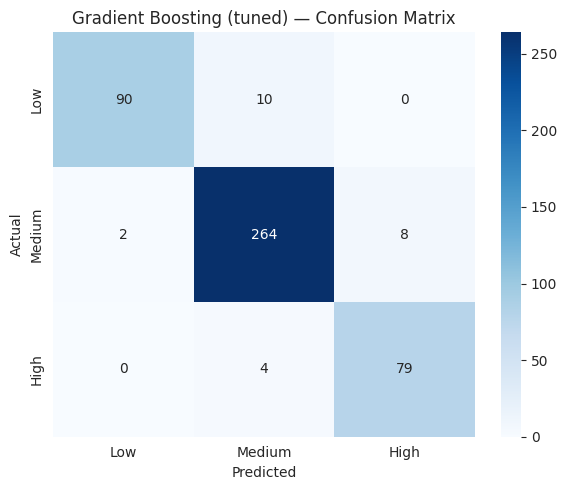

In [ ]:
results = []
for name, model in trained.items():
    if name == 'Logistic Regression (baseline)':
        pred = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)
    else:
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='macro'),
        'Recall': recall_score(y_test, pred, average='macro'),
        'F1': f1_score(y_test, pred, average='macro'),
        'AUC-ROC': roc_auc_score(y_test, proba, multi_class='ovr'),
    })
results_df = pd.DataFrame(results)
print('MODEL COMPARISON Merchant Value Tier (Low / Medium / High)')
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
print(results_df.to_string(index=False, formatters={c: '{:.3f}'.format for c in metric_cols}))
# --- Selected model ---
best_name = 'Gradient Boosting (tuned)'
best_model = trained[best_name]
pred = best_model.predict(X_test)
best_row = results_df[results_df['Model'] == best_name].iloc[0]
print(f'\nSelected model: {best_name}')
print(f'\n{best_name} — Per-Class Report:')
print(classification_report(y_test, pred, target_names=['Low', 'Medium', 'High'], digits=3))
# --- Confusion Matrix ---
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, pred)
print(f'\n{best_name} — Confusion Matrix:')
cm_df = pd.DataFrame(cm, index=[f'Actual {l}' for l in labels], columns=[f'Predicted {l}' for l in labels])
print(cm_df.to_string())
# --- Confusion Matrix heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{best_name} — Confusion Matrix')
plt.tight_layout()
plt.show()

#SECTION 9: Overfitting Check - Train vs Test F1 (Bar Chart)

###An overfitting check was performed by comparing each model's F1 score on the training set versus the test set, visualized as a grouped bar chart, with a Train-Test gap exceeding **0.10-0.15** taken as an indicator of meaningful overfitting

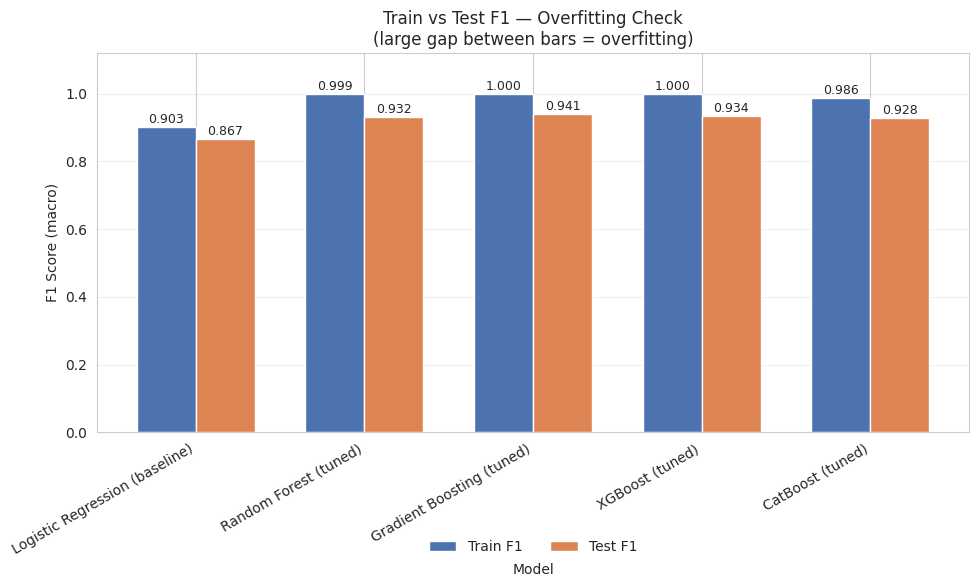

                         Model  Train F1  Test F1  Gap
Logistic Regression (baseline)      0.90     0.87 0.04
         Random Forest (tuned)      1.00     0.93 0.07
     Gradient Boosting (tuned)      1.00     0.94 0.06
               XGBoost (tuned)      1.00     0.93 0.07
              CatBoost (tuned)      0.99     0.93 0.06


In [ ]:
overfit_results = []
for name, model in trained.items():
    if name == 'Logistic Regression (baseline)':
        pred_train = model.predict(X_train_bal_scaled)
        pred_test = model.predict(X_test_scaled)
        y_tr = y_train_bal
    else:
        pred_train = model.predict(X_train_bal)
        pred_test = model.predict(X_test)
        y_tr = y_train_bal

    f1_train = f1_score(y_tr, pred_train, average='macro')
    f1_test = f1_score(y_test, pred_test, average='macro')
    overfit_results.append({'Model': name, 'Train F1': f1_train, 'Test F1': f1_test})

overfit_df = pd.DataFrame(overfit_results)

# --- Grouped bar chart: Train vs Test F1 side by side per model ---
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(overfit_df))
width = 0.35

bars1 = ax.bar(x - width/2, overfit_df['Train F1'], width, label='Train F1', color='#4C72B0')
bars2 = ax.bar(x + width/2, overfit_df['Test F1'], width, label='Test F1', color='#DD8452')

ax.set_xlabel('Model')
ax.set_ylabel('F1 Score (macro)')
ax.set_title('Train vs Test F1 — Overfitting Check\n(large gap between bars = overfitting)')
ax.set_xticks(x)
ax.set_xticklabels(overfit_df['Model'], rotation=30, ha='right')
ax.set_ylim(0, 1.12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)
ax.grid(axis='y', alpha=0.3)

# --- Label each bar with its value ---
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# --- Print the gap explicitly too ---
overfit_df['Gap'] = overfit_df['Train F1'] - overfit_df['Test F1']
print(overfit_df.round(4).to_string(index=False))
# gap > 0.10-0.15 suggests meaningful overfitting